In [1]:
#URL = https://www.kaggle.com/competitions/digit-recognizer/overview

In [2]:
import pandas as pd
import numpy as np
dataset = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Digit_Recognizer/train.csv')
x_train = dataset.drop(columns = 'label')
y_train = dataset['label']

In [3]:
x_train = x_train.values.reshape(-1,28,28,1)
x_train = x_train.astype(np.float32) / 255

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    layers.Input(shape = (28,28,1)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    
    layers.Conv2D(filters = 32,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),
    
    layers.Conv2D(filters = 64,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),
    
    layers.Conv2D(filters = 128,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),
    
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(rate = 0.25),
    layers.Dense(units = 64,activation = 'relu'),
    layers.Dense(units = 10,activation = 'softmax')
])


In [5]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['sparse_categorical_accuracy']
)

In [6]:
history = model.fit(
    x_train,
    y_train,
    validation_split = 0.2,
    epochs = 50,
    callbacks = [EarlyStopping(monitor = 'val_loss', patience = 15, restore_best_weights = True)]
)

Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.3666 - sparse_categorical_accuracy: 0.8851 - val_loss: 0.5311 - val_sparse_categorical_accuracy: 0.8354
Epoch 2/50
 211/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1674 - sparse_categorical_accuracy: 0.9468

KeyboardInterrupt: 

In [ ]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

<Axes: >

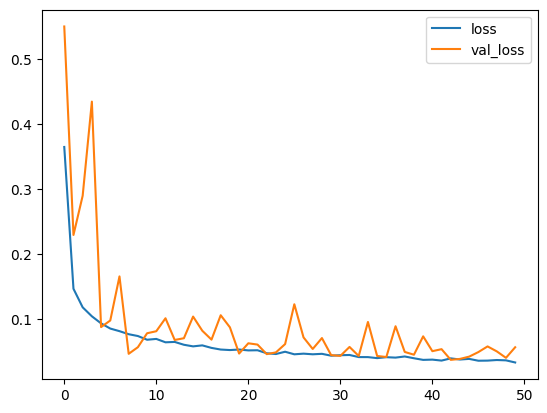

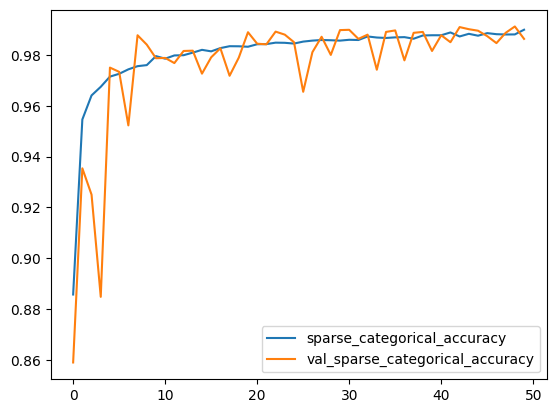

In [ ]:
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['sparse_categorical_accuracy', 'val_sparse_categorical_accuracy']].plot()

In [ ]:
import numpy as np
x_test = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Digit_Recognizer/test.csv')
x_test = x_test.values.reshape(-1,28,28,1)
x_test = x_test.astype(np.float32) / 255
pred = model.predict(x_test)
pred = np.argmax(pred, axis=1)

submission = pd.DataFrame({
    "ImageId" : [id for id in range(1,x_test.shape[0] + 1)],
    "Label" : pred
})
submission.to_csv('submission.csv',index = False)

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
